In [29]:
from setupimp import RUN_FULL_MODEL, RUN_ORBIT_CORRECTION_EXAMPLE, repo_root
import pandas as pd
import sys
from pathlib import Path

from optics_gui.snapshot import (
    SnapshotConfig,
    SnapshotOrbitCorrectionConfig,
    copy_snapshot_config,
    build_machine_snapshot,
)
from optics_gui.orbit_correction import (
    bpm_measurements_from_twiss,
    normalise_bpm_measurements,
    normalise_corrector_selection,
    plot_orbit_with_bpm,
    plot_corrector_suggestions,
)

orbit_base_config = SnapshotConfig(
    cycle_time_ms=0.0,
    requested_qx=4.31,
    requested_qy=3.83,
    lattice_folder=str(repo_root / "Dev" / "Lattice_Files" / "00_Simplified_Lattice"),
    output_dir=str(repo_root / "Dev" / "12_IO" / "student_runs" / "orbit"),
    run_envelope=False,
    run_aperture=False,
)

jan26_error_table = repo_root / "Dev" / "Error_Tables" / "jan26_survey_corrected.tfs"
if not jan26_error_table.is_file():
    raise FileNotFoundError(f"Expected error table at {jan26_error_table}")


In [23]:

def select_correctors_for_demo(plane, corrector_names):
    correctors = normalise_corrector_selection(plane=plane)
    selected = {name.lower() for name in corrector_names}
    correctors["enabled"] = correctors["corrector"].str.lower().isin(selected)
    return correctors

if RUN_FULL_MODEL and RUN_ORBIT_CORRECTION_EXAMPLE:
    error_orbit_config = copy_snapshot_config(
        orbit_base_config,
        snapshot_id="student_error_table_orbit",
        label="student error-table orbit",
        error_table_paths=[str(jan26_error_table)],
        orbit_correction_configs=[],
    )
    error_orbit_snapshot = build_machine_snapshot(error_orbit_config)

    error_orbit_bpm_h = bpm_measurements_from_twiss(error_orbit_snapshot.table("twiss"), plane="H")
    error_orbit_bpm_v = bpm_measurements_from_twiss(error_orbit_snapshot.table("twiss"), plane="V")

    h_correctors = select_correctors_for_demo("H", ["r0hd1_kick", "r3hd1_kick", "r5hd1_kick", "r9hd1_kick"])
    v_correctors = select_correctors_for_demo("V", ["r0vd1_kick", "r3vd1_kick", "r5vd1_kick", "r9vd1_kick"])

    error_orbit_correction_config = copy_snapshot_config(
        orbit_base_config,
        snapshot_id="student_error_table_orbit_correction",
        label="student error-table orbit correction",
        error_table_paths=[str(jan26_error_table)],
        orbit_correction_configs=[
            SnapshotOrbitCorrectionConfig(
                plane="H",
                label="horizontal_error_table_orbit",
                bpm_measurements=error_orbit_bpm_h,
                correctors=h_correctors,
            ),
            SnapshotOrbitCorrectionConfig(
                plane="V",
                label="vertical_error_table_orbit",
                bpm_measurements=error_orbit_bpm_v,
                correctors=v_correctors,
            ),
        ],
    )
    error_orbit_correction_snapshot = build_machine_snapshot(error_orbit_correction_config)
    display(error_orbit_correction_snapshot.table("orbit_correction_summary"))
    display(error_orbit_correction_snapshot.table("orbit_correction_correctors"))
else:
    print("Correction example skipped. Keep RUN_FULL_MODEL and RUN_ORBIT_CORRECTION_EXAMPLE true to run it.")


,snapshot_id,correction_label,plane,read_only,workflow,n_seed_bpm,n_seed_fit_knobs,n_enabled_correctors,before_n_monitor,before_rms_orbit_mm,before_max_abs_orbit_mm,before_mean_orbit_mm,after_n_monitor,after_rms_orbit_mm,after_max_abs_orbit_mm,after_mean_orbit_mm,rms_change_mm
0,student_error_table_orbit_correction,horizontal_error_table_orbit,H,True,bpm_match_then_madx_correct,16,10,4,16,0.0,0.0,0.0,16,0.0,0.0,0.0,0.0
1,student_error_table_orbit_correction,vertical_error_table_orbit,V,True,bpm_match_then_madx_correct,20,10,4,20,0.0,0.0,0.0,20,0.0,0.0,0.0,0.0


,snapshot_id,correction_label,corrector,plane,superperiod,enabled,initial_kick_rad,matched_kick_rad,delta_kick_rad,delta_kick_mrad,delta_current_A
0,student_error_table_orbit_correction,horizontal_error_table_orbit,r0hd1_kick,H,0,True,0.0,0.0,0.0,0.0,0.0
1,student_error_table_orbit_correction,horizontal_error_table_orbit,r2hd1_kick,H,2,False,0.0,0.0,0.0,0.0,0.0
2,student_error_table_orbit_correction,horizontal_error_table_orbit,r3hd1_kick,H,3,True,0.0,0.0,0.0,0.0,0.0
3,student_error_table_orbit_correction,horizontal_error_table_orbit,r4hd1_kick,H,4,False,0.0,0.0,0.0,0.0,0.0
4,student_error_table_orbit_correction,horizontal_error_table_orbit,r5hd1_kick,H,5,True,0.0,0.0,0.0,0.0,0.0
5,student_error_table_orbit_correction,horizontal_error_table_orbit,r7hd1_kick,H,7,False,0.0,0.0,0.0,0.0,0.0
6,student_error_table_orbit_correction,horizontal_error_table_orbit,r9hd1_kick,H,9,True,0.0,0.0,0.0,0.0,0.0
7,student_error_table_orbit_correction,vertical_error_table_orbit,r0vd1_kick,V,0,True,0.0,0.0,0.0,0.0,0.0
8,student_error_table_orbit_correction,vertical_error_table_orbit,r2vd1_kick,V,2,False,0.0,0.0,0.0,0.0,0.0
9,student_error_table_orbit_correction,vertical_error_table_orbit,r3vd1_kick,V,3,True,0.0,0.0,0.0,0.0,0.0


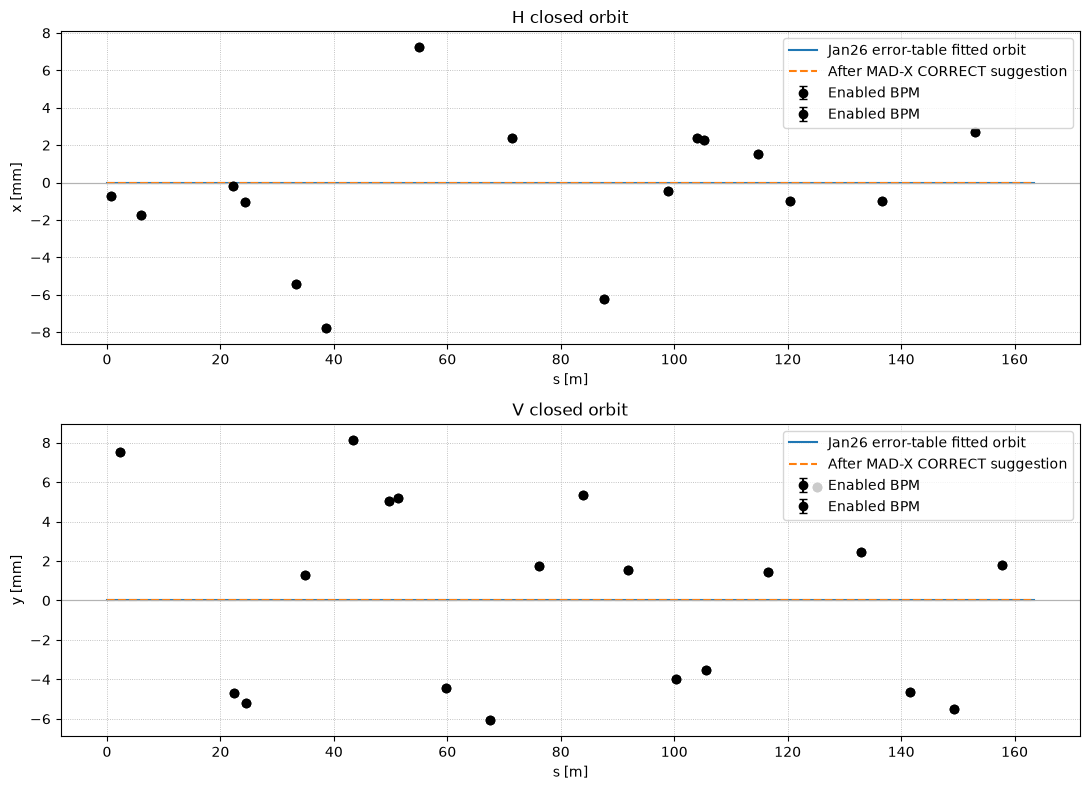

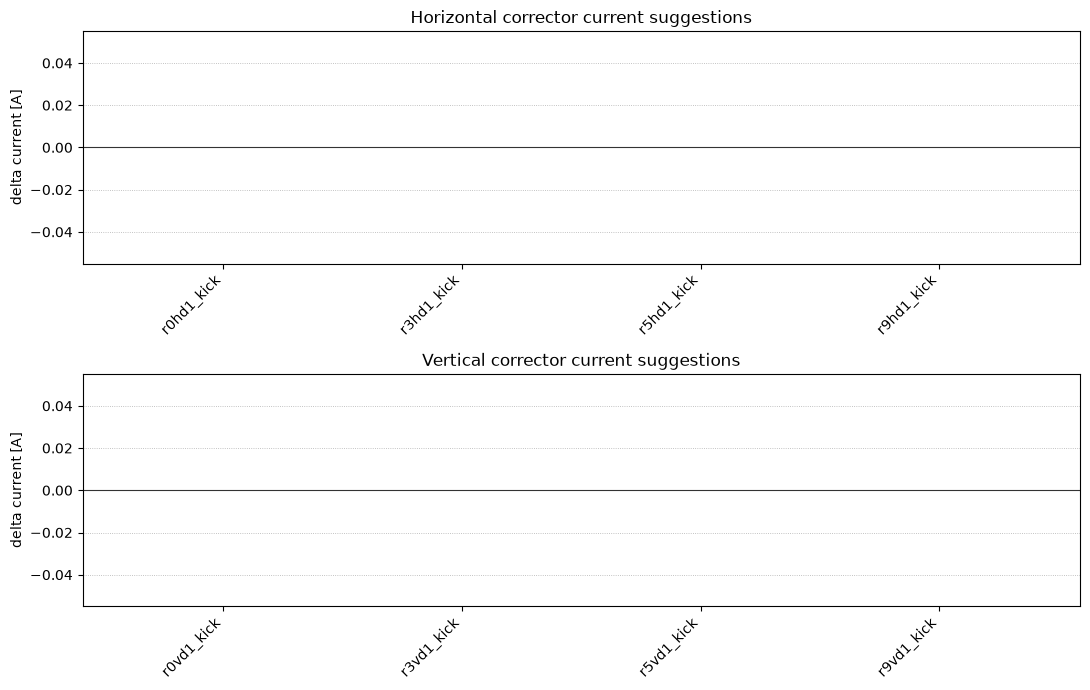

In [30]:
#correction plots bweh

import matplotlib.pyplot as plt

if RUN_FULL_MODEL and RUN_ORBIT_CORRECTION_EXAMPLE:
    h_correction = next(result.result for result in error_orbit_correction_snapshot.orbit_correction_results if result.plane == "H")
    v_correction = next(result.result for result in error_orbit_correction_snapshot.orbit_correction_results if result.plane == "V")

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)
    plot_orbit_with_bpm(
        h_correction.measured_twiss_df,
        h_correction.bpm_measurements,
        plane="H",
        ax=axes[0],
        label="Jan26 error-table fitted orbit",
        title="Horizontal orbit before and after correction suggestion",
    )
    plot_orbit_with_bpm(
        h_correction.corrected_twiss_df,
        h_correction.bpm_measurements,
        plane="H",
        ax=axes[0],
        label="After MAD-X CORRECT suggestion",
        orbit_kwargs={"linestyle": "--"},
    )
    plot_orbit_with_bpm(
        v_correction.measured_twiss_df,
        v_correction.bpm_measurements,
        plane="V",
        ax=axes[1],
        label="Jan26 error-table fitted orbit",
        title="Vertical orbit before and after correction suggestion",
    )
    plot_orbit_with_bpm(
        v_correction.corrected_twiss_df,
        v_correction.bpm_measurements,
        plane="V",
        ax=axes[1],
        label="After MAD-X CORRECT suggestion",
        orbit_kwargs={"linestyle": "--"},
    )
    fig.tight_layout()

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)
    plot_corrector_suggestions(
        h_correction.correctors,
        ax=axes[0],
        value="delta_current_A",
        title="Horizontal corrector current suggestions",
    )
    plot_corrector_suggestions(
        v_correction.correctors,
        ax=axes[1],
        value="delta_current_A",
        title="Vertical corrector current suggestions",
    )
    fig.tight_layout()
else:
    print("Correction plots skipped. Keep RUN_FULL_MODEL and RUN_ORBIT_CORRECTION_EXAMPLE true to run them.")

In [ ]:
# Show the current correction suggestions for the selected correctors.
# This block uses the correction snapshot tables directly, which is the most
# reliable way to display the values that the backend actually produced.
if RUN_FULL_MODEL and RUN_ORBIT_CORRECTION_EXAMPLE:
    correction_summary = error_orbit_correction_snapshot.table("orbit_correction_summary")
    correction_correctors = error_orbit_correction_snapshot.table("orbit_correction_correctors")

    display(correction_summary)
    display(correction_correctors)

    # Plot the selected corrector suggestions for the two planes.
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)
    plot_corrector_suggestions(
        correction_correctors[correction_correctors["plane"] == "H"],
        ax=axes[0],
        value="delta_current_A",
        title="Horizontal corrector suggestions",
    )
    plot_corrector_suggestions(
        correction_correctors[correction_correctors["plane"] == "V"],
        ax=axes[1],
        value="delta_current_A",
        title="Vertical corrector suggestions",
    )
    fig.tight_layout()
else:
    print("Correction suggestions skipped. Set RUN_FULL_MODEL and RUN_ORBIT_CORRECTION_EXAMPLE to True to display them.")

Dummy BPM matched-orbit plot skipped. Set RUN_FULL_MODEL = True and RUN_ORBIT_CORRECTION_EXAMPLE = True to run this heavier example.
